# Milestone 2 — Analiza endpointów

Mapowanie 63 endpointów → 28 zdarzenia, normalizacja (collapse per-instance CPEE → 15 typów),
redukcja wymiarowości (PCA/UMAP), klasteryzacja hierarchiczna i walidacja klastrów
względem 8 docelowych zdarzeń.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

ROOT = Path('.').resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = ROOT / 'results' / 'm2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def shorten_url(url):
    url = url.replace('https://', '').replace('https-get://', 'GET:').replace('https-post://', 'POST:')
    url = url.rstrip('/')
    if len(url) > 55:
        url = url[:52] + '...'
    return url

TARGET_ACTIVITIES = [
    'Callback timeout', 'Export result', 'Export to EMS',
    'Match patient data', 'Receive sample state',
    'Send notification', 'Wait for plate validation', 'timeout',
]

D:\BU\DataMining2026PCALabData\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_events = pd.read_parquet(PROCESSED_DIR / 'pcr_events_biz.parquet')
df_cases = pd.read_parquet(PROCESSED_DIR / 'pcr_cases.parquet')

# Zdarzenia start (unikamy dublowania start+complete)
df_start = df_events[
    (df_events['lifecycle'] == 'start') &
    df_events['endpoint'].notna() &
    (df_events['endpoint'] != '')
].copy()

print(f'Zdarzenia start z endpointem: {len(df_start):,}')
print(f'Unikalne endpointy: {df_start["endpoint"].nunique()}')
print(f'Unikalne zdarzenia: {df_start["activity"].nunique()}')
print(f'\n8 zdarzen do walidacji: {TARGET_ACTIVITIES}')

Zdarzenia start z endpointem: 51,209
Unikalne endpointy: 63
Unikalne zdarzenia: 28

8 zdarzen do walidacji: ['Callback timeout', 'Export result', 'Export to EMS', 'Match patient data', 'Receive sample state', 'Send notification', 'Wait for plate validation', 'timeout']


## 1. Macierz endpoint × zdarzenie

Budujemy macierz 63×28 (endpointy × zdarzenia). 49 z 63 to adresy instancji silnika CPEE
(`cpee.org/flow/engine/{id}/...`), różniące się jedynie identyfikatorem —
normalizujemy je do jednego typu → **15 logicznych endpointów**.

In [3]:
matrix_raw = df_start.groupby(['endpoint', 'activity']).size().unstack(fill_value=0)
print(f'Macierz surowa: {matrix_raw.shape[0]} endpointow x {matrix_raw.shape[1]} zdarzen')

def normalize_endpoint(url):
    return re.sub(r'/engine/\d+/', '/engine/{id}/', url)

df_start['ep_norm'] = df_start['endpoint'].apply(normalize_endpoint)
n_collapsed = df_start['endpoint'].nunique() - df_start['ep_norm'].nunique()
print(f'Po normalizacji: {df_start["ep_norm"].nunique()} typow (zwinieto {n_collapsed} per-instance URL)')

matrix = df_start.groupby(['ep_norm', 'activity']).size().unstack(fill_value=0)
print(f'Macierz robocza: {matrix.shape[0]} x {matrix.shape[1]}')

Macierz surowa: 63 endpointow x 28 zdarzen
Po normalizacji: 15 typow (zwinieto 48 per-instance URL)


Macierz robocza: 15 x 28


In [4]:
totals = matrix.sum(axis=1)
shares = matrix.div(totals, axis=0)
n_act = (matrix > 0).sum(axis=1)
dom_act = shares.idxmax(axis=1)
dom_share = shares.max(axis=1)

mapping_type = pd.Series('multi', index=matrix.index)
mapping_type[n_act == 1] = '1:1'
mapping_type[(n_act > 1) & (dom_share >= 0.95)] = 'mostly'

print('Typ mapowania (endpoint -> zdarzenia):')
print(mapping_type.value_counts().to_string())
print()

for mt in ['1:1', 'mostly', 'multi']:
    subset_idx = mapping_type[mapping_type == mt].index
    if len(subset_idx) == 0:
        continue
    print(f'--- {mt} ({len(subset_idx)}) ---')
    for ep in subset_idx:
        acts = matrix.columns[matrix.loc[ep] > 0].tolist()
        print(f'  {shorten_url(ep)}')
        print(f'    -> {acts}')
    print()

Typ mapowania (endpoint -> zdarzenia):


multi     9
1:1       5
mostly    1

--- 1:1 (5) ---
  cpee.org/services/powernap.php
    -> ['Sleep']
  greschner.azurewebsites.net/backend/services/notifyall
    -> ['Send notification']
  greschner.azurewebsites.net/backend/services/pcheck
    -> ['Check for unfinished Plates']
  mygreschner.com/backend/services/notifyall
    -> ['Send notification']
  mygreschner.com/backend/services/pcheck
    -> ['Check for unfinished Plates']

--- mostly (1) ---
  cpee.org/flow/start/url
    -> ['Finish wellplate watcher', 'Spawn Single Wellplate', 'Spawn per sample flow']

--- multi (9) ---
  GET:cpee.org/ing/correlators/message/receive
    -> ['Receive finishids', 'Wait for finished plate', 'Wait for plate validation']
  POST:cpee.org/ing/correlators/message/send
    -> ['Notify per wellplate subprocess', 'Notify plain instance', 'Send plate validation']
  cpee.org/flow/engine/{id}/properties/state
    -> ['Abandon spawned sample', 'Stopping spawned sample']
  greschner.azurewebsites.net/backe

### Odwrotne mapowanie: zdarzenie → endpointy

Sprawdzamy czy niektóre endpointy łączą się w jedno zdarzenie (np. 2 endpointy = 1 zadanie).

In [5]:
print('Zdarzenie -> endpointy:\n')
for act in sorted(matrix.columns):
    eps = matrix.index[matrix[act] > 0].tolist()
    target_mark = ' *' if act in TARGET_ACTIVITIES else ''
    print(f'{act}{target_mark}: {len(eps)} endpoint(ow)')
    for ep in eps:
        count = matrix.loc[ep, act]
        print(f'    {shorten_url(ep)}: {count:,}')

print('\n* = jedno z 8 zdarzen do walidacji')

Zdarzenie -> endpointy:

Abandon spawned sample: 1 endpoint(ow)
    cpee.org/flow/engine/{id}/properties/state: 49
Callback timeout *: 3 endpoint(ow)
    greschner.azurewebsites.net/backend/services/timeout: 676
    greschner.azurewebsites.net/backend/services/timeout2: 313
    mygreschner.com/backend/services/timeout2: 4,778
Check for unfinished Plates: 2 endpoint(ow)
    greschner.azurewebsites.net/backend/services/pcheck: 1,078
    mygreschner.com/backend/services/pcheck: 635
Delete: Wait for sample: 1 endpoint(ow)
    greschner.azurewebsites.net/backend/corr: 167
Delete: Wait for sample delete: 1 endpoint(ow)
    greschner.azurewebsites.net/backend/corr: 167
Export result *: 2 endpoint(ow)
    greschner.azurewebsites.net/backend/corr: 172
    mygreschner.com//backend/corr: 649
Export to EMS *: 2 endpoint(ow)
    greschner.azurewebsites.net/backend/corr: 172
    mygreschner.com//backend/corr: 649
Finish wellplate: 2 endpoint(ow)
    greschner.azurewebsites.net/backend/corr: 3
    my

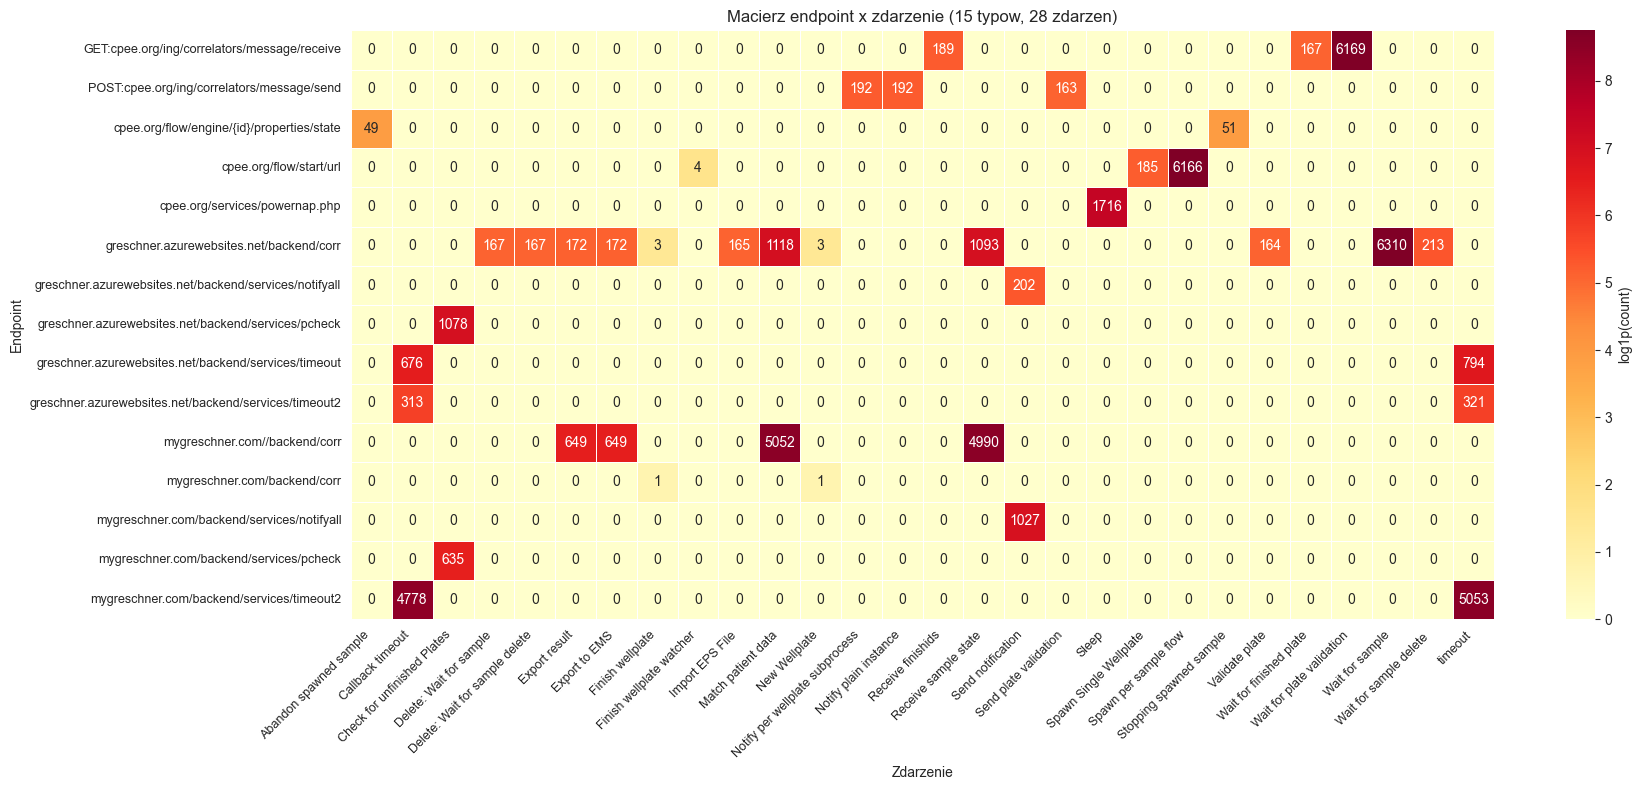

In [6]:
labels_y = [shorten_url(ep) for ep in matrix.index]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    np.log1p(matrix.values),
    annot=matrix.values, fmt='d',
    xticklabels=matrix.columns.tolist(),
    yticklabels=labels_y,
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'log1p(count)'}
)
ax.set_title('Macierz endpoint x zdarzenie (15 typow, 28 zdarzen)')
ax.set_xlabel('Zdarzenie')
ax.set_ylabel('Endpoint')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_endpoint_activity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Normalizacja i redukcja wymiarowości

Normalizacja: `log1p` + `StandardScaler`.
Redukcja: PCA (2D) i UMAP (2D). Kolorujemy wg typu mapowania (1:1 / mostly / multi).

Wariancja wyjasniona: PC1=34.9%, PC2=11.5%, suma=46.4%


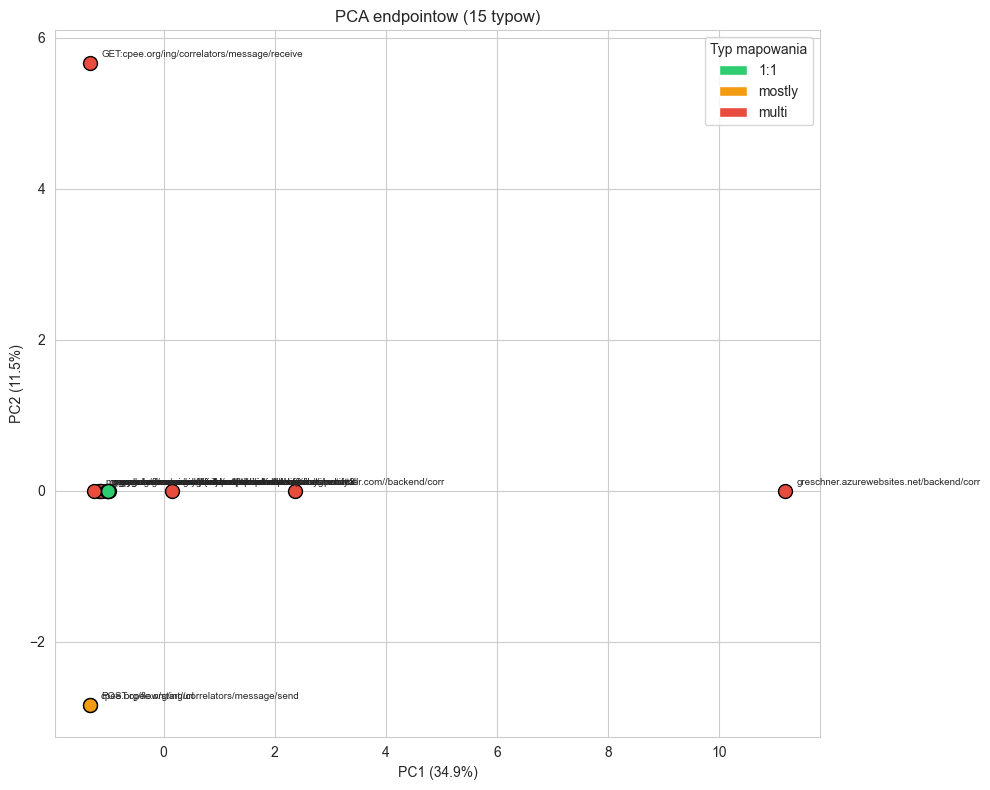

In [7]:
X = np.log1p(matrix.values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Wariancja wyjasniona: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}, '
      f'suma={sum(pca.explained_variance_ratio_):.1%}')

color_map = {'1:1': '#2ecc71', 'mostly': '#f39c12', 'multi': '#e74c3c'}
colors = [color_map[mapping_type[ep]] for ep in matrix.index]

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='1:1'),
    Patch(facecolor='#f39c12', label='mostly'),
    Patch(facecolor='#e74c3c', label='multi'),
]

fig, ax = plt.subplots(figsize=(10, 8))
for i, ep in enumerate(matrix.index):
    ax.scatter(X_pca[i, 0], X_pca[i, 1], c=colors[i], s=100, edgecolors='black', zorder=3)
    ax.annotate(shorten_url(ep), (X_pca[i, 0], X_pca[i, 1]),
                textcoords='offset points', xytext=(8, 4), fontsize=7)

ax.legend(handles=legend_elements, title='Typ mapowania', loc='best')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA endpointow (15 typow)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_pca_endpoints.png', dpi=150, bbox_inches='tight')
plt.show()

D:\BU\DataMining2026PCALabData\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


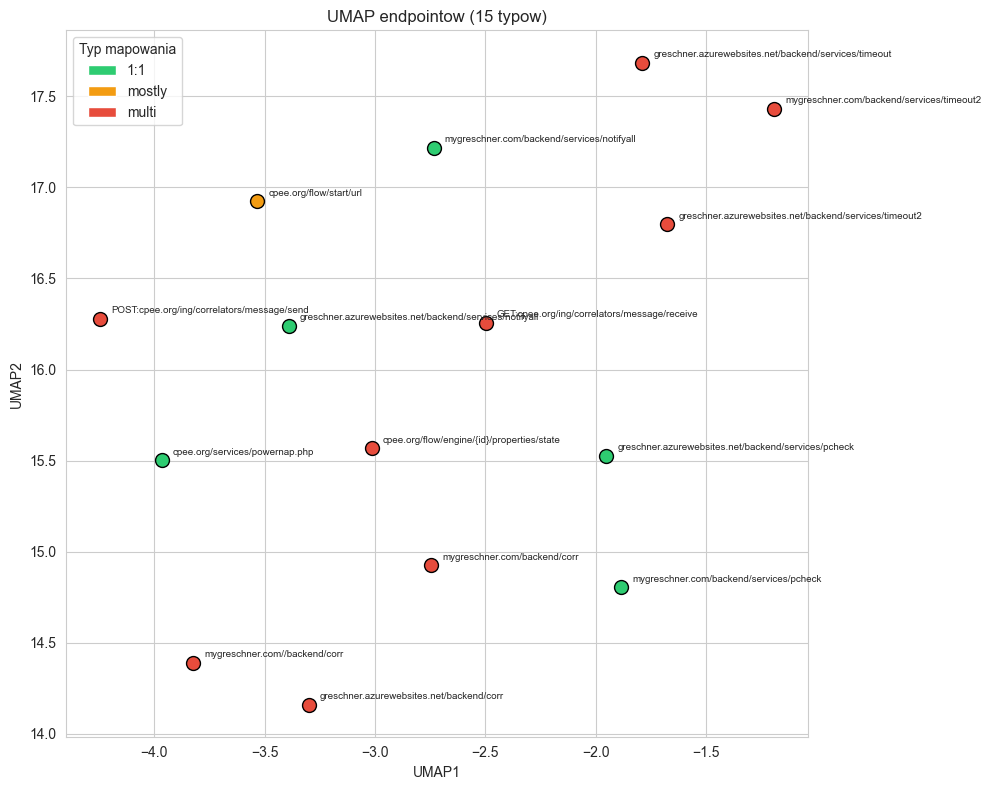

In [8]:
um = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=RANDOM_STATE)
X_umap = um.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for i, ep in enumerate(matrix.index):
    ax.scatter(X_umap[i, 0], X_umap[i, 1], c=colors[i], s=100, edgecolors='black', zorder=3)
    ax.annotate(shorten_url(ep), (X_umap[i, 0], X_umap[i, 1]),
                textcoords='offset points', xytext=(8, 4), fontsize=7)

ax.legend(handles=legend_elements, title='Typ mapowania', loc='best')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('UMAP endpointow (15 typow)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_umap_endpoints.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Klasteryzacja i walidacja

Klasteryzacja hierarchiczna (Ward) z dendrogramem.
Walidacja: czy klastry grupują endpointy obsługujące te same zdarzenia?

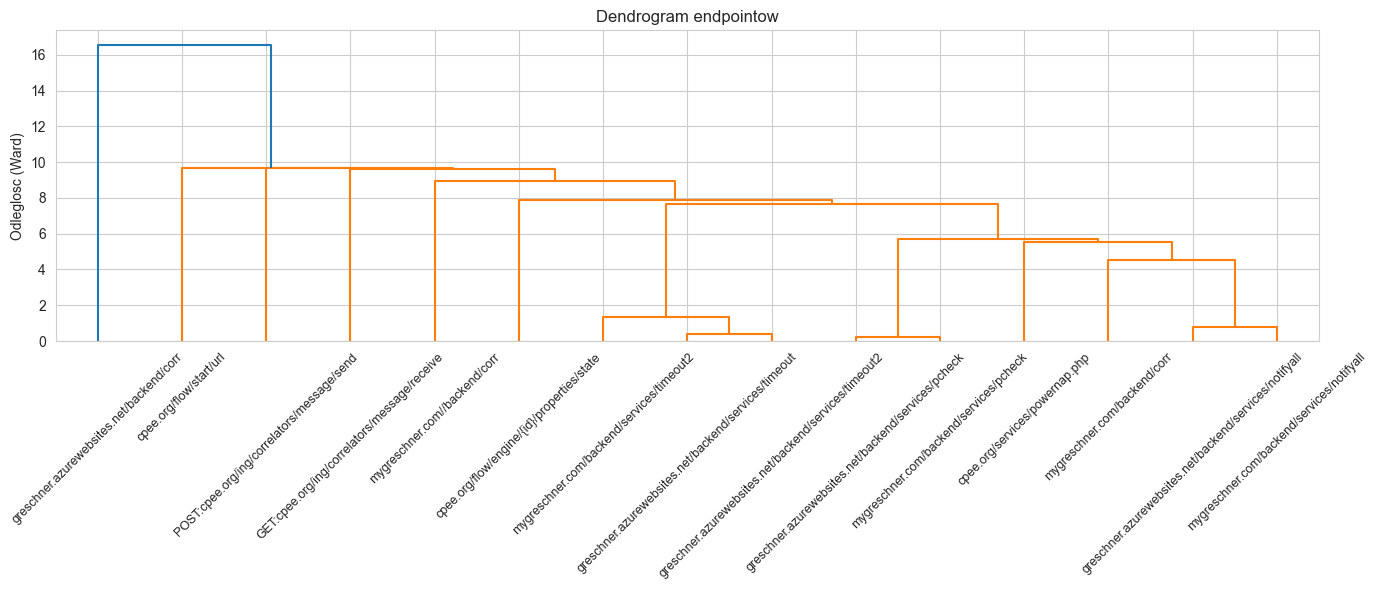

In [9]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
labels_short = [shorten_url(ep) for ep in matrix.index]
dn = dendrogram(Z, labels=labels_short, ax=ax, leaf_rotation=45, leaf_font_size=9,
                color_threshold=0.7 * max(Z[:, 2]))
ax.set_ylabel('Odleglosc (Ward)')
ax.set_title('Dendrogram endpointow')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_dendrogram_endpoints.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
for n_clusters in [3, 5, 8]:
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

    if len(set(clusters)) > 1:
        sil = silhouette_score(X_scaled, clusters)
    else:
        sil = float('nan')

    print(f'=== k={n_clusters}, silhouette={sil:.3f} ===')

    for c in sorted(set(clusters)):
        eps_in = [matrix.index[i] for i in range(len(clusters)) if clusters[i] == c]
        all_acts = set()
        for ep in eps_in:
            for col in matrix.columns:
                if matrix.loc[ep, col] > 0:
                    all_acts.add(col)

        ep_labels = [shorten_url(e) for e in eps_in]
        target_acts = sorted(a for a in all_acts if a in TARGET_ACTIVITIES)
        other_acts = sorted(a for a in all_acts if a not in TARGET_ACTIVITIES)
        print(f'  Klaster {c} ({len(eps_in)} endp.): {ep_labels}')
        print(f'    Zdarzenia: {sorted(all_acts)}')
        if target_acts:
            print(f'    W tym z 8 docelowych: {target_acts}')
    print()

=== k=3, silhouette=0.250 ===
  Klaster 1 (13 endp.): ['GET:cpee.org/ing/correlators/message/receive', 'POST:cpee.org/ing/correlators/message/send', 'cpee.org/flow/engine/{id}/properties/state', 'cpee.org/services/powernap.php', 'greschner.azurewebsites.net/backend/services/notifyall', 'greschner.azurewebsites.net/backend/services/pcheck', 'greschner.azurewebsites.net/backend/services/timeout', 'greschner.azurewebsites.net/backend/services/timeout2', 'mygreschner.com//backend/corr', 'mygreschner.com/backend/corr', 'mygreschner.com/backend/services/notifyall', 'mygreschner.com/backend/services/pcheck', 'mygreschner.com/backend/services/timeout2']
    Zdarzenia: ['Abandon spawned sample', 'Callback timeout', 'Check for unfinished Plates', 'Export result', 'Export to EMS', 'Finish wellplate', 'Match patient data', 'New Wellplate', 'Notify per wellplate subprocess', 'Notify plain instance', 'Receive finishids', 'Receive sample state', 'Send notification', 'Send plate validation', 'Sleep', 

## 4. Podsumowanie

### Mapowanie endpoint → zdarzenie

- 63 surowe endpointy → **15 logicznych typów** (49 per-instance CPEE engine URL zwiniętych do 1).
- Typ mapowania: **5 endpointów 1:1**, **1 mostly**, **9 multi**.
- Mapowanie jest wiele-do-wielu: jeden endpoint (np. `*/backend/corr`) obsługuje do 12 zdarzeń, a jedno zdarzenie (np. `timeout`) korzysta z 3 endpointów.

### Łączenie endpointów

- Dwa endpointy tego samego serwisu na różnych domenach (`mygreschner.com` vs `greschner.azurewebsites.net`) obsługują te same zdarzenia — dendrogram łączy je na najniższym poziomie.
- Wyjątek: `greschner.azurewebsites.net/backend/corr` obsługuje dodatkowe zdarzenia (Import EPS File, Validate plate, Wait/Delete for sample), których brak w `mygreschner.com//backend/corr` — dlatego nie trafiają do tego samego klastra przy wyższych k.

### PCA/UMAP

- PCA: PC1+PC2 = 46.4% wariancji. `greschner.azurewebsites.net/backend/corr` jest wyraźnym outlierem (obsługuje 12 zdarzeń).
- UMAP: lepsza separacja — widoczne grupy: timeout (góra-prawo), backend/corr (dół), serwisy CPEE (lewo).
- Kolorowanie wg typu mapowania: endpointy multi (czerwone) są rozproszone, 1:1 (zielone) skupiają się na peryferiach.

### Klasteryzacja

- Klasteryzacja hierarchiczna (Ward) przy k=8:
  - Timeout serwisy (3 endpointy) → Callback timeout + timeout.
  - Dwa `*/backend/corr` w osobnych klastrach (różny zakres zdarzeń).
  - Korelatory CPEE, flow/start, engine/{id} — każdy w osobnym klastrze.
- Silhouette: k=5 najlepszy (0.273), k=3 (0.250), k=8 (0.230) — niskie wartości wynikają z małego n=15.

### Walidacja względem 8 zdarzeń

- 8 z 15 endpointów obsługuje co najmniej jedno z 8 docelowych zdarzeń.
- Klastry grupują endpointy wg funkcji serwisowej (timeout, notyfikacje, korelacja), nie wg typu procesu.
- Endpointy to **serwisy wielokrotnego użytku** współdzielone między procesami, nie dedykowane moduły per zdarzenie.
